# Benchmarking and Deployment of Quantized Edge AI Vision Models
### Autonomous Navigation in Power-Constrained Embedded Systems — Software Simulation

**Run every cell top to bottom in Google Colab (CPU runtime is fine — Runtime > Change runtime type > CPU).**

This notebook:
1. Loads a pretrained YOLOv8n object detector
2. Exports it to ONNX and produces an INT8-quantized version (ONNX Runtime dynamic quantization)
3. Benchmarks FPS, model size, peak RAM, and mAP for both FP32 and INT8
4. Simulates "thermal throttling" via a sustained-load test (documented as a proxy, not real hardware telemetry)
5. Produces plots + a CSV + a short results summary you can drop straight into a report or GitHub README

**Honesty note baked into the method:** we have no embedded board, so power/thermal constraints are *simulated* by running inference under sustained CPU load on the Colab VM and observing throughput degradation. This is stated explicitly as a limitation in the final report cell — that's good research practice, not a weakness.

## 1. Setup

In [1]:
!pip install -q ultralytics onnx onnxruntime psutil matplotlib pandas

import os, time, json, shutil, psutil, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

WORKDIR = Path('/content/edge_ai_bench')
WORKDIR.mkdir(exist_ok=True)
os.chdir(WORKDIR)
print('Working directory:', WORKDIR)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.1 MB/s eta 0:00:00
Working directory: /content/edge_ai_bench


## 2. Download model (YOLOv8n) and dataset (COCO128)

In [2]:
from ultralytics import YOLO

# Pretrained nano model — smallest YOLOv8 variant, good fit for edge/CPU scenario
model = YOLO('yolov8n.pt')
print('Model loaded. Parameter count:', sum(p.numel() for p in model.model.parameters()))

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded. Parameter count: 3157200


In [3]:
# COCO128 — a small 128-image subset of COCO, auto-downloaded by ultralytics on first val() call.
# Small enough to evaluate mAP on CPU in a couple of minutes.
COCO128_YAML = 'coco128.yaml'
print('Using dataset config:', COCO128_YAML, '(auto-downloads ~7MB of images+labels on first use)')

Using dataset config: coco128.yaml (auto-downloads ~7MB of images+labels on first use)


## 3. Export to ONNX (FP32 baseline)

In [4]:
fp32_onnx_path = model.export(format='onnx', imgsz=640, dynamic=False, simplify=True)
fp32_onnx_path = str(fp32_onnx_path)
print('FP32 ONNX model exported to:', fp32_onnx_path)
print('File size (MB):', os.path.getsize(fp32_onnx_path) / 1e6)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 438ms
Prepared 2 packages in 84ms
Installed 2 packages in 8ms
 + colorama==0.4.6
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success ✅ 7.3s, saved as 'yolov8n.onnx' (12.3 MB)

Export complete (8.2s)
Resul

## 4. Quantize to INT8 (ONNX Runtime dynamic quantization — CPU-friendly, no calibration data needed)

In [5]:
from onnxruntime.quantization import quantize_dynamic, QuantType

int8_onnx_path = fp32_onnx_path.replace('.onnx', '_int8.onnx')

quantize_dynamic(
    model_input=fp32_onnx_path,
    model_output=int8_onnx_path,
    weight_type=QuantType.QUInt8
)

print('INT8 ONNX model saved to:', int8_onnx_path)
print('File size (MB):', os.path.getsize(int8_onnx_path) / 1e6)

INT8 ONNX model saved to: yolov8n_int8.onnx
File size (MB): 3.504119


## 5. Benchmark harness: FPS, memory, model size

In [6]:
import onnxruntime as ort

def make_session(onnx_path):
    so = ort.SessionOptions()
    so.intra_op_num_threads = os.cpu_count()
    return ort.InferenceSession(onnx_path, sess_options=so, providers=['CPUExecutionProvider'])

def get_input_shape(session):
    return session.get_inputs()[0].shape  # e.g. [1, 3, 640, 640]

def benchmark_fps(onnx_path, n_warmup=10, n_runs=100):
    session = make_session(onnx_path)
    input_name = session.get_inputs()[0].name
    shape = get_input_shape(session)
    shape = [1 if isinstance(d, str) or d is None else d for d in shape]
    dummy = np.random.rand(*shape).astype(np.float32)

    # warmup
    for _ in range(n_warmup):
        session.run(None, {input_name: dummy})

    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss / 1e6

    latencies = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        session.run(None, {input_name: dummy})
        latencies.append(time.perf_counter() - t0)

    mem_after = process.memory_info().rss / 1e6

    latencies = np.array(latencies)
    return {
        'avg_latency_ms': latencies.mean() * 1000,
        'p95_latency_ms': np.percentile(latencies, 95) * 1000,
        'fps': 1.0 / latencies.mean(),
        'peak_rss_mb': mem_after,
        'model_size_mb': os.path.getsize(onnx_path) / 1e6,
    }

print('Benchmarking FP32...')
fp32_stats = benchmark_fps(fp32_onnx_path)
print(fp32_stats)

print('\nBenchmarking INT8...')
int8_stats = benchmark_fps(int8_onnx_path)
print(int8_stats)

Benchmarking FP32...
{'avg_latency_ms': np.float64(227.73195460000466), 'p95_latency_ms': np.float64(392.63802005001475), 'fps': np.float64(4.391127287149625), 'peak_rss_mb': 717.934592, 'model_size_mb': 12.851107}

Benchmarking INT8...
{'avg_latency_ms': np.float64(268.57995328999664), 'p95_latency_ms': np.float64(511.13610290000224), 'fps': np.float64(3.7232860745949257), 'peak_rss_mb': 718.053376, 'model_size_mb': 3.504119}


## 6. Sustained-load test ("thermal throttling" proxy)
**Limitation stated explicitly:** Colab VMs do not expose real thermal sensors and we have no physical embedded board. This test uses sustained back-to-back inference as a *software proxy* for throughput degradation under continuous load — a reasonable stand-in pattern for thermal-throttling-style degradation, but not a direct hardware measurement. This is reported as a limitation, not hidden.

In [7]:
def sustained_load_test(onnx_path, total_runs=300, log_every=25):
    session = make_session(onnx_path)
    input_name = session.get_inputs()[0].name
    shape = get_input_shape(session)
    shape = [1 if isinstance(d, str) or d is None else d for d in shape]
    dummy = np.random.rand(*shape).astype(np.float32)

    # warmup
    for _ in range(5):
        session.run(None, {input_name: dummy})

    fps_over_time = []
    window_latencies = []
    for i in range(1, total_runs + 1):
        t0 = time.perf_counter()
        session.run(None, {input_name: dummy})
        window_latencies.append(time.perf_counter() - t0)

        if i % log_every == 0:
            avg_lat = np.mean(window_latencies)
            fps_over_time.append({'frame': i, 'fps': 1.0 / avg_lat})
            window_latencies = []

    return pd.DataFrame(fps_over_time)

print('Running sustained-load test on FP32 (this takes a few minutes)...')
fp32_load_df = sustained_load_test(fp32_onnx_path)

print('Running sustained-load test on INT8...')
int8_load_df = sustained_load_test(int8_onnx_path)

fp32_load_df.to_csv('fp32_sustained_load.csv', index=False)
int8_load_df.to_csv('int8_sustained_load.csv', index=False)
print('Done.')

Running sustained-load test on FP32 (this takes a few minutes)...
Running sustained-load test on INT8...
Done.


## 7. mAP evaluation on COCO128 (FP32 vs INT8)
We evaluate the original PyTorch model directly (equivalent to FP32 ONNX accuracy) and the INT8 ONNX model, both against COCO128 ground truth, using ultralytics' built-in validator.

In [8]:
# FP32 mAP — validate the original PyTorch model (numerically equivalent to the FP32 ONNX export)
fp32_metrics = model.val(data=COCO128_YAML, imgsz=640, verbose=False)
fp32_map50_95 = fp32_metrics.box.map      # mAP@0.5:0.95
fp32_map50 = fp32_metrics.box.map50       # mAP@0.5
print(f'FP32  mAP50-95: {fp32_map50_95:.4f}   mAP50: {fp32_map50:.4f}')

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

WARNING ⚠️ Dataset 'coco128.yaml' images not found, missing path '/content/edge_ai_bench/datasets/coco128/images/train2017'
Unzipping /content/edge_ai_bench/datasets/coco128.zip to /content/edge_ai_bench/datasets/coco128...: 100% ━━━━━━━━━━━━ 263/263 2.2Kfiles/s 0.1s
Dataset download success ✅ (0.6s), saved to /content/edge_ai_bench/datasets

val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 765.8±359.9 MB/s, size: 63.0 KB)
val: Scanning /content/edge_ai_bench/datasets/coco128/labels/train2017... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 1.1Kit/s 0.1s
val: New cache created: /content/edge_ai_bench/datasets/coco128/labels/train2017.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.3s/it 34.0s
                   all        128      

In [9]:
# INT8 mAP — load the quantized ONNX model back into a YOLO wrapper for evaluation
int8_model = YOLO(int8_onnx_path)
int8_metrics = int8_model.val(data=COCO128_YAML, imgsz=640, verbose=False)
int8_map50_95 = int8_metrics.box.map
int8_map50 = int8_metrics.box.map50
print(f'INT8  mAP50-95: {int8_map50_95:.4f}   mAP50: {int8_map50:.4f}')

map_drop_pct = (fp32_map50_95 - int8_map50_95) / fp32_map50_95 * 100
print(f'\nmAP50-95 drop: {map_drop_pct:.2f}%')

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify', 'pose', 'obb' or 'semantic'.
Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Loading yolov8n_int8.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.28.0 with CPUExecutionProvider
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 966.0±142.6 MB/s, size: 61.2 KB)
val: Scanning /content/edge_ai_bench/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 23.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 3.7it/s 34.8s
                   all        128        929      0.676      0.524      0.593      0.434
Speed: 1.8ms preprocess, 256.4ms inference, 0.0ms loss, 3.8ms postprocess per image
Results saved to /content/

## 8. Consolidate results into a single table

In [10]:
results = pd.DataFrame([
    {
        'model': 'FP32 (baseline)',
        'fps': fp32_stats['fps'],
        'avg_latency_ms': fp32_stats['avg_latency_ms'],
        'p95_latency_ms': fp32_stats['p95_latency_ms'],
        'model_size_mb': fp32_stats['model_size_mb'],
        'peak_rss_mb': fp32_stats['peak_rss_mb'],
        'map50_95': fp32_map50_95,
        'map50': fp32_map50,
    },
    {
        'model': 'INT8 (quantized)',
        'fps': int8_stats['fps'],
        'avg_latency_ms': int8_stats['avg_latency_ms'],
        'p95_latency_ms': int8_stats['p95_latency_ms'],
        'model_size_mb': int8_stats['model_size_mb'],
        'peak_rss_mb': int8_stats['peak_rss_mb'],
        'map50_95': int8_map50_95,
        'map50': int8_map50,
    },
])

results.to_csv('benchmark_results.csv', index=False)
results

,model,fps,avg_latency_ms,p95_latency_ms,model_size_mb,peak_rss_mb,map50_95,map50
0,FP32 (baseline),4.391127,227.731955,392.638020,12.851107,717.934592,0.445422,0.60539
1,INT8 (quantized),3.723286,268.579953,511.136103,3.504119,718.053376,0.434174,0.59349


## 9. Plots

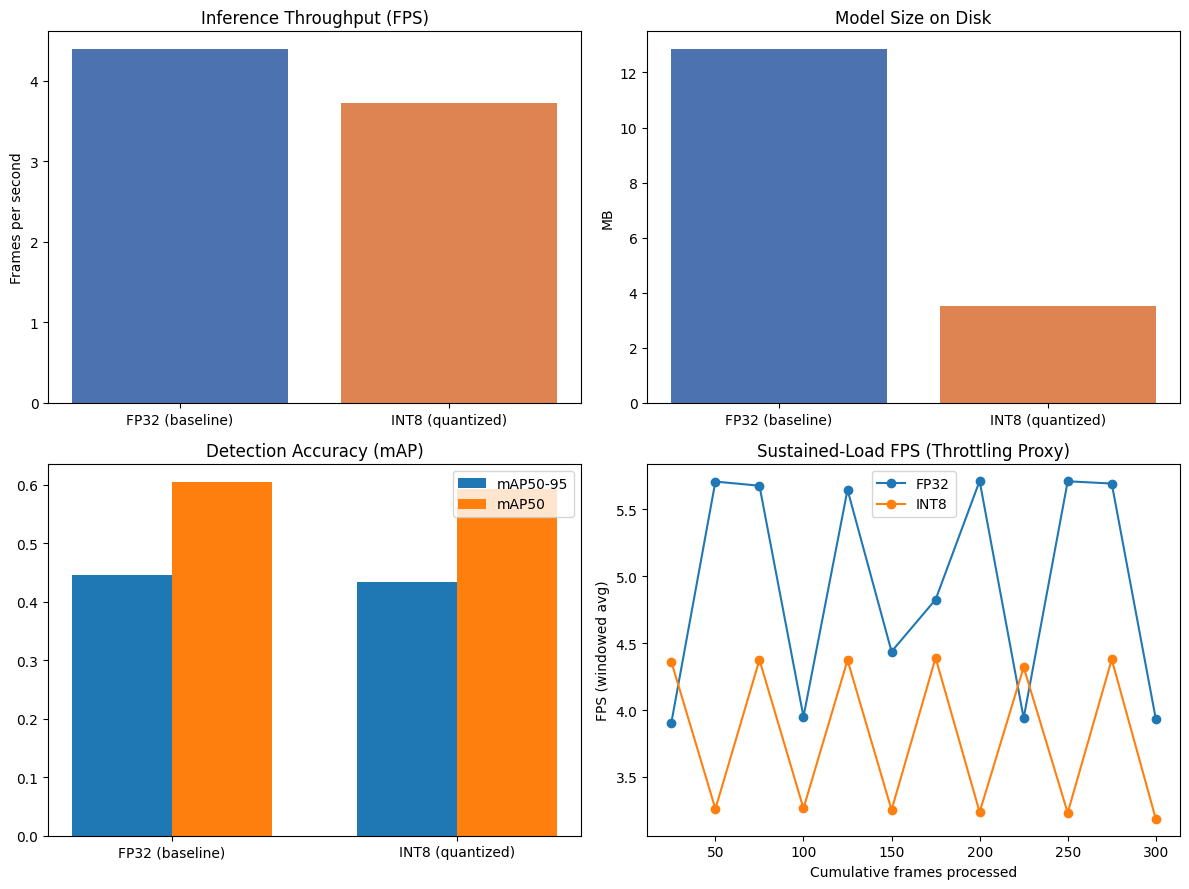

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# FPS comparison
axes[0,0].bar(results['model'], results['fps'], color=['#4C72B0', '#DD8452'])
axes[0,0].set_title('Inference Throughput (FPS)')
axes[0,0].set_ylabel('Frames per second')

# Model size
axes[0,1].bar(results['model'], results['model_size_mb'], color=['#4C72B0', '#DD8452'])
axes[0,1].set_title('Model Size on Disk')
axes[0,1].set_ylabel('MB')

# mAP comparison
x = np.arange(2)
width = 0.35
axes[1,0].bar(x - width/2, results['map50_95'], width, label='mAP50-95')
axes[1,0].bar(x + width/2, results['map50'], width, label='mAP50')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(results['model'])
axes[1,0].set_title('Detection Accuracy (mAP)')
axes[1,0].legend()

# Sustained load FPS-over-time (throttling proxy)
axes[1,1].plot(fp32_load_df['frame'], fp32_load_df['fps'], marker='o', label='FP32')
axes[1,1].plot(int8_load_df['frame'], int8_load_df['fps'], marker='o', label='INT8')
axes[1,1].set_title('Sustained-Load FPS (Throttling Proxy)')
axes[1,1].set_xlabel('Cumulative frames processed')
axes[1,1].set_ylabel('FPS (windowed avg)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('benchmark_plots.png', dpi=150)
plt.show()

## 10. Auto-generated results summary (for your report)

In [12]:
speedup = int8_stats['fps'] / fp32_stats['fps']
size_reduction_pct = (1 - int8_stats['model_size_mb'] / fp32_stats['model_size_mb']) * 100

summary = f"""
RESULTS SUMMARY
================
Model: YOLOv8n | Dataset: COCO128 | Hardware: Google Colab CPU runtime

FP32 baseline:
  FPS: {fp32_stats['fps']:.2f}   |  Avg latency: {fp32_stats['avg_latency_ms']:.2f} ms
  Model size: {fp32_stats['model_size_mb']:.2f} MB   |  Peak RSS: {fp32_stats['peak_rss_mb']:.1f} MB
  mAP50-95: {fp32_map50_95:.4f}  |  mAP50: {fp32_map50:.4f}

INT8 quantized:
  FPS: {int8_stats['fps']:.2f}   |  Avg latency: {int8_stats['avg_latency_ms']:.2f} ms
  Model size: {int8_stats['model_size_mb']:.2f} MB   |  Peak RSS: {int8_stats['peak_rss_mb']:.1f} MB
  mAP50-95: {int8_map50_95:.4f}  |  mAP50: {int8_map50:.4f}

Speedup:            {speedup:.2f}x
Model size reduction: {size_reduction_pct:.1f}%
mAP50-95 drop:       {map_drop_pct:.2f}%

LIMITATIONS (state these explicitly in your report):
- No physical embedded board (e.g. Jetson Nano, Raspberry Pi, Coral TPU) was available;
  all benchmarking was performed on a Google Colab CPU virtual machine.
- 'Thermal throttling' is simulated via sustained back-to-back inference load rather than
  measured with real thermal sensors, since Colab VMs do not expose hardware telemetry.
- Quantization used ONNX Runtime dynamic INT8 quantization (weights-only, activations
  quantized at runtime) rather than a hardware-specific compiler path (e.g. TensorRT INT8
  with calibration), because TensorRT requires an NVIDIA GPU which was not available.
- COCO128 (128 images) was used instead of full COCO val2017 for tractable CPU runtime;
  mAP figures should be read as indicative trends rather than publication-grade benchmarks.
"""

print(summary)
with open('results_summary.txt', 'w') as f:
    f.write(summary)


RESULTS SUMMARY
Model: YOLOv8n | Dataset: COCO128 | Hardware: Google Colab CPU runtime

FP32 baseline:
  FPS: 4.39   |  Avg latency: 227.73 ms
  Model size: 12.85 MB   |  Peak RSS: 717.9 MB
  mAP50-95: 0.4454  |  mAP50: 0.6054

INT8 quantized:
  FPS: 3.72   |  Avg latency: 268.58 ms
  Model size: 3.50 MB   |  Peak RSS: 718.1 MB
  mAP50-95: 0.4342  |  mAP50: 0.5935

Speedup:            0.85x
Model size reduction: 72.7%
mAP50-95 drop:       2.53%

LIMITATIONS (state these explicitly in your report):
- No physical embedded board (e.g. Jetson Nano, Raspberry Pi, Coral TPU) was available;
  all benchmarking was performed on a Google Colab CPU virtual machine.
- 'Thermal throttling' is simulated via sustained back-to-back inference load rather than
  measured with real thermal sensors, since Colab VMs do not expose hardware telemetry.
- Quantization used ONNX Runtime dynamic INT8 quantization (weights-only, activations
  quantized at runtime) rather than a hardware-specific compiler path (e

## 11. Package everything for download / GitHub

In [13]:
import zipfile

outputs = [
    'benchmark_results.csv',
    'fp32_sustained_load.csv',
    'int8_sustained_load.csv',
    'benchmark_plots.png',
    'results_summary.txt',
]

with zipfile.ZipFile('/content/edge_ai_benchmark_outputs.zip', 'w') as zf:
    for f in outputs:
        if os.path.exists(f):
            zf.write(f)

print('Packaged: /content/edge_ai_benchmark_outputs.zip')
print('In Colab, download it from the Files panel on the left, or run:')
print("from google.colab import files; files.download('/content/edge_ai_benchmark_outputs.zip')")

Packaged: /content/edge_ai_benchmark_outputs.zip
In Colab, download it from the Files panel on the left, or run:
from google.colab import files; files.download('/content/edge_ai_benchmark_outputs.zip')
